# Parte 2: EDA Avanzado y Topologico - Elliptic Bitcoin Dataset
## Justificacion Arquitectonica para Graph Neural Networks

**Tesis de Posgrado** | Basado en tecnicas del estado del arte (2024-2026)

---

> Este notebook asume que los datos ya fueron cargados y el grafo base `G` existe en memoria
> (ver Parte 1 del EDA). Aqui profundizamos en analisis topologicos avanzados para responder
> preguntas criticas de diseno:
>
> 1. **GCN vs GAT vs GraphSAGE?** -> Analisis de Asortatividad
> 2. **Cuantas capas?** -> Analisis de Over-Smoothing
> 3. **Que features usar?** -> Topological Feature Informativeness
> 4. **Como manejar los unknowns?** -> Dinamica de nodos desconocidos
> 5. **Que patrones topologicos buscar?** -> Mineria de Motifs

---

## Setup: Carga de Datos y Construccion del Grafo

In [1]:
import kagglehub
path = kagglehub.dataset_download('ellipticco/elliptic-data-set')
print(f'Dataset en: {path}')

c:\Proyectos\thesis\gnns_thesis\semana_1\notebooks\eda_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset en: C:\Users\analista3.datos\.cache\kagglehub\datasets\ellipticco\elliptic-data-set\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.3)
plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 150,
    'font.family': 'serif', 'axes.titlesize': 14, 'axes.labelsize': 12,
    'savefig.bbox': 'tight', 'savefig.dpi': 300
})
SEED = 42
np.random.seed(SEED)

import os
os.makedirs('./figuras', exist_ok=True)

# --- Cargar datos ---
feat_cols = ['txId', 'timestep'] + [f'feat_{i}' for i in range(1, 167)]
df_features = pd.read_csv(path + '/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None, names=feat_cols)
df_classes = pd.read_csv(path + '/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')
df_classes.columns = ['txId', 'class']
df_edges = pd.read_csv(path + '/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')
df_edges.columns = ['txId1', 'txId2']

CLASS_MAP = {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
df_classes['class'] = df_classes['class'].astype(str).map(CLASS_MAP)
df = df_features.merge(df_classes, on='txId', how='left')
LABEL_MAP = {'illicit': 1, 'licit': 0, 'unknown': -1}
df['label'] = df['class'].map(LABEL_MAP)

# --- Construir grafo ---
G = nx.DiGraph()
for _, row in df[['txId', 'timestep', 'class', 'label']].iterrows():
    G.add_node(row['txId'], timestep=row['timestep'], node_class=row['class'], label=row['label'])
valid_nodes = set(G.nodes())
edges_valid = df_edges[df_edges['txId1'].isin(valid_nodes) & df_edges['txId2'].isin(valid_nodes)]
G.add_edges_from(edges_valid.values.tolist())

print(f"Grafo: {G.number_of_nodes():,} nodos, {G.number_of_edges():,} aristas")
print(f"Clases: {df['class'].value_counts().to_dict()}")

Grafo: 203,769 nodos, 234,355 aristas
Clases: {'unknown': 157205, 'licit': 42019, 'illicit': 4545}


---
# 1. Analisis de Asortatividad Local y Temporal

## Fundamento Matematico

La **asortatividad de Newman** mide la correlacion entre atributos de nodos conectados.
Para atributos categoricos (illicit/licit), se define como:

$$r = \frac{\sum_i e_{ii} - \sum_i a_i b_i}{1 - \sum_i a_i b_i}$$

donde $e_{ij}$ es la fraccion de aristas que conectan nodos de tipo $i$ con tipo $j$,
$a_i = \sum_j e_{ij}$ y $b_j = \sum_i e_{ij}$.

- $r > 0$: **Asortativo** (homofilia) -> Los nodos tienden a conectarse con nodos de la misma clase -> **GCN** funciona bien.
- $r \approx 0$: Sin patron.
- $r < 0$: **Disasortativo** (heterofilia) -> Nodos de distinta clase se conectan -> Se necesita **GAT** con atencion selectiva.

### Asortatividad Local
La asortatividad global puede ocultar heterogeneidad. Calculamos asortatividad *por vecindario*
para detectar zonas del grafo donde la homofilia se rompe.

In [3]:
# === 1.1 Asortatividad Global de Newman ===
# Solo considerar nodos con label conocido
labeled_nodes = [n for n in G.nodes() if G.nodes[n].get('label', -1) >= 0]
G_labeled = G.subgraph(labeled_nodes).copy()

r_global = nx.attribute_assortativity_coefficient(G_labeled, 'label')
print(f"=== Asortatividad Global de Newman ===")
print(f"r = {r_global:.4f}")

if r_global > 0.3:
    print("-> ALTA homofilia: GCN con message passing estandar es adecuado.")
elif r_global > 0.0:
    print("-> Homofilia MODERADA: GCN funciona, pero GAT podria capturar matices.")
else:
    print("-> HETEROFILIA: Se requiere GAT, GraphSAGE, o arquitecturas heterofilia-aware (H2GCN).")

=== Asortatividad Global de Newman ===
r = 0.5163
-> ALTA homofilia: GCN con message passing estandar es adecuado.


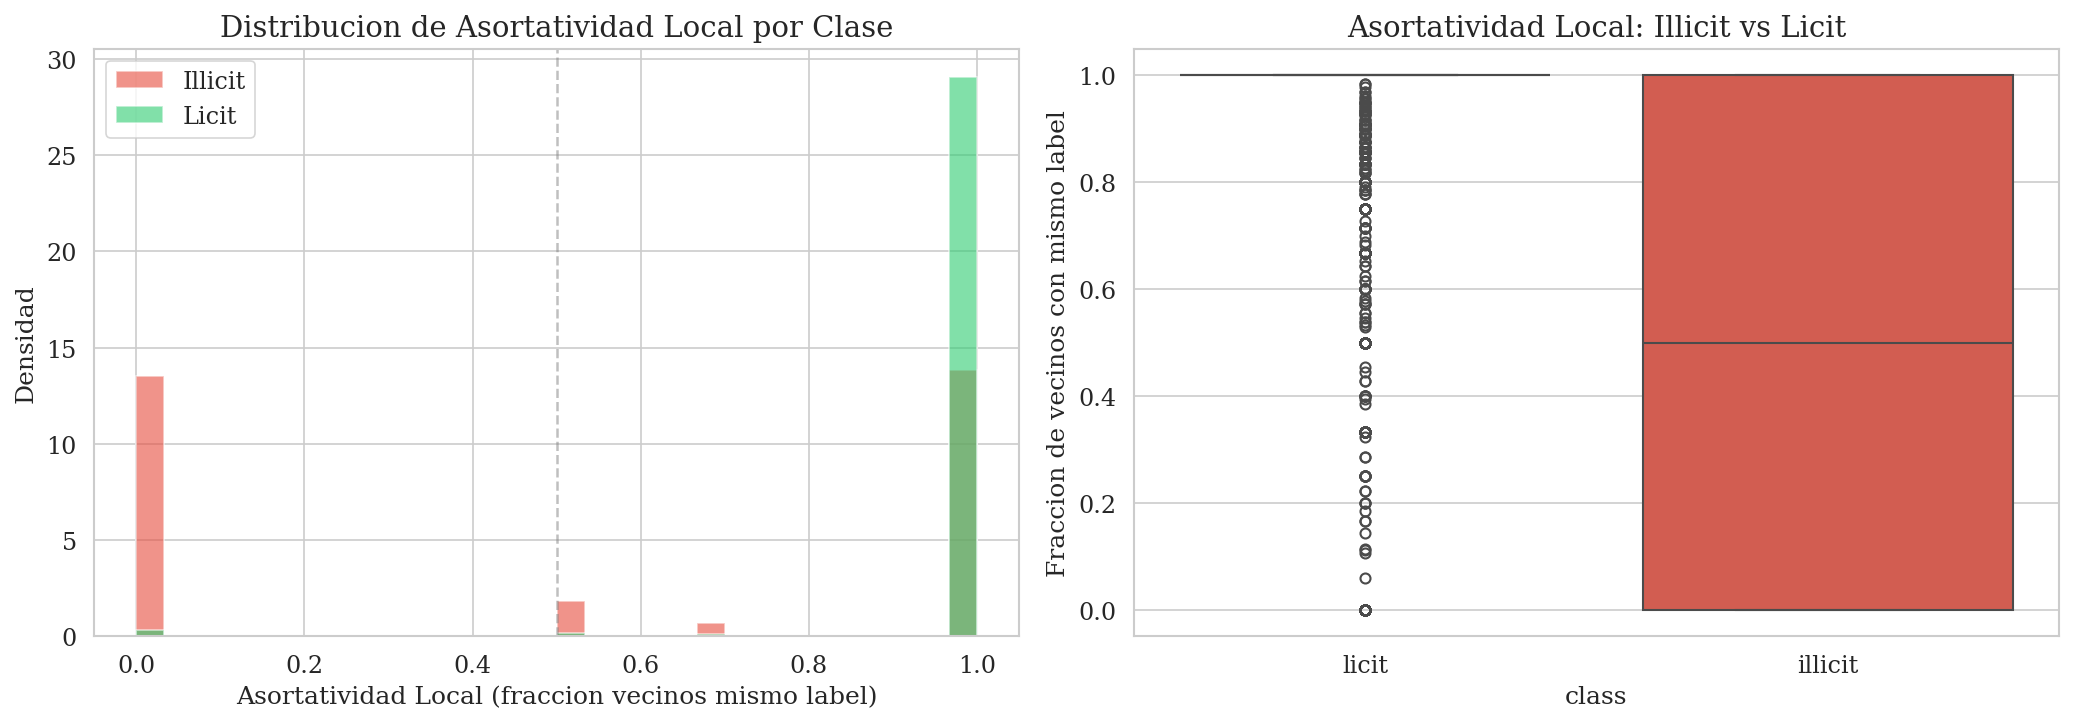

ILLICIT: mean=0.510, median=0.500, fraction<0.5=0.452
LICIT: mean=0.982, median=1.000, fraction<0.5=0.012


In [4]:
# === 1.2 Asortatividad Local por Nodo ===
def local_assortativity(G, node, label_attr='label'):
    """
    Calcula la asortatividad local para un nodo:
    fraccion de vecinos con el mismo label.
    """
    node_label = G.nodes[node].get(label_attr, -1)
    if node_label < 0:
        return np.nan
    neighbors = list(G.predecessors(node)) + list(G.successors(node))
    labeled_neighbors = [n for n in neighbors if G.nodes[n].get(label_attr, -1) >= 0]
    if len(labeled_neighbors) == 0:
        return np.nan
    same = sum(1 for n in labeled_neighbors if G.nodes[n][label_attr] == node_label)
    return same / len(labeled_neighbors)

# Calcular para todos los nodos etiquetados
local_assort = {}
for node in labeled_nodes:
    la = local_assortativity(G, node)
    if not np.isnan(la):
        local_assort[node] = la

df['local_assort'] = df['txId'].map(local_assort)

# Distribucion de asortatividad local por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_cls = {'illicit': '#e74c3c', 'licit': '#2ecc71'}

for cls, color in colors_cls.items():
    vals = df.loc[df['class'] == cls, 'local_assort'].dropna()
    axes[0].hist(vals, bins=30, alpha=0.6, color=color, label=cls.capitalize(), density=True)

axes[0].set_xlabel('Asortatividad Local (fraccion vecinos mismo label)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribucion de Asortatividad Local por Clase')
axes[0].legend(frameon=True)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Aleatorio')

# Boxplot
df_box = df[df['class'].isin(['illicit', 'licit'])]
sns.boxplot(data=df_box, x='class', y='local_assort', ax=axes[1], palette=colors_cls)
axes[1].set_title('Asortatividad Local: Illicit vs Licit')
axes[1].set_ylabel('Fraccion de vecinos con mismo label')

plt.tight_layout()
plt.savefig('./figuras/local_assortativity.png', dpi=300)
plt.show()

# Estadisticas
for cls in ['illicit', 'licit']:
    vals = df.loc[df['class'] == cls, 'local_assort'].dropna()
    print(f"{cls.upper()}: mean={vals.mean():.3f}, median={vals.median():.3f}, "
          f"fraction<0.5={( vals < 0.5).mean():.3f}")

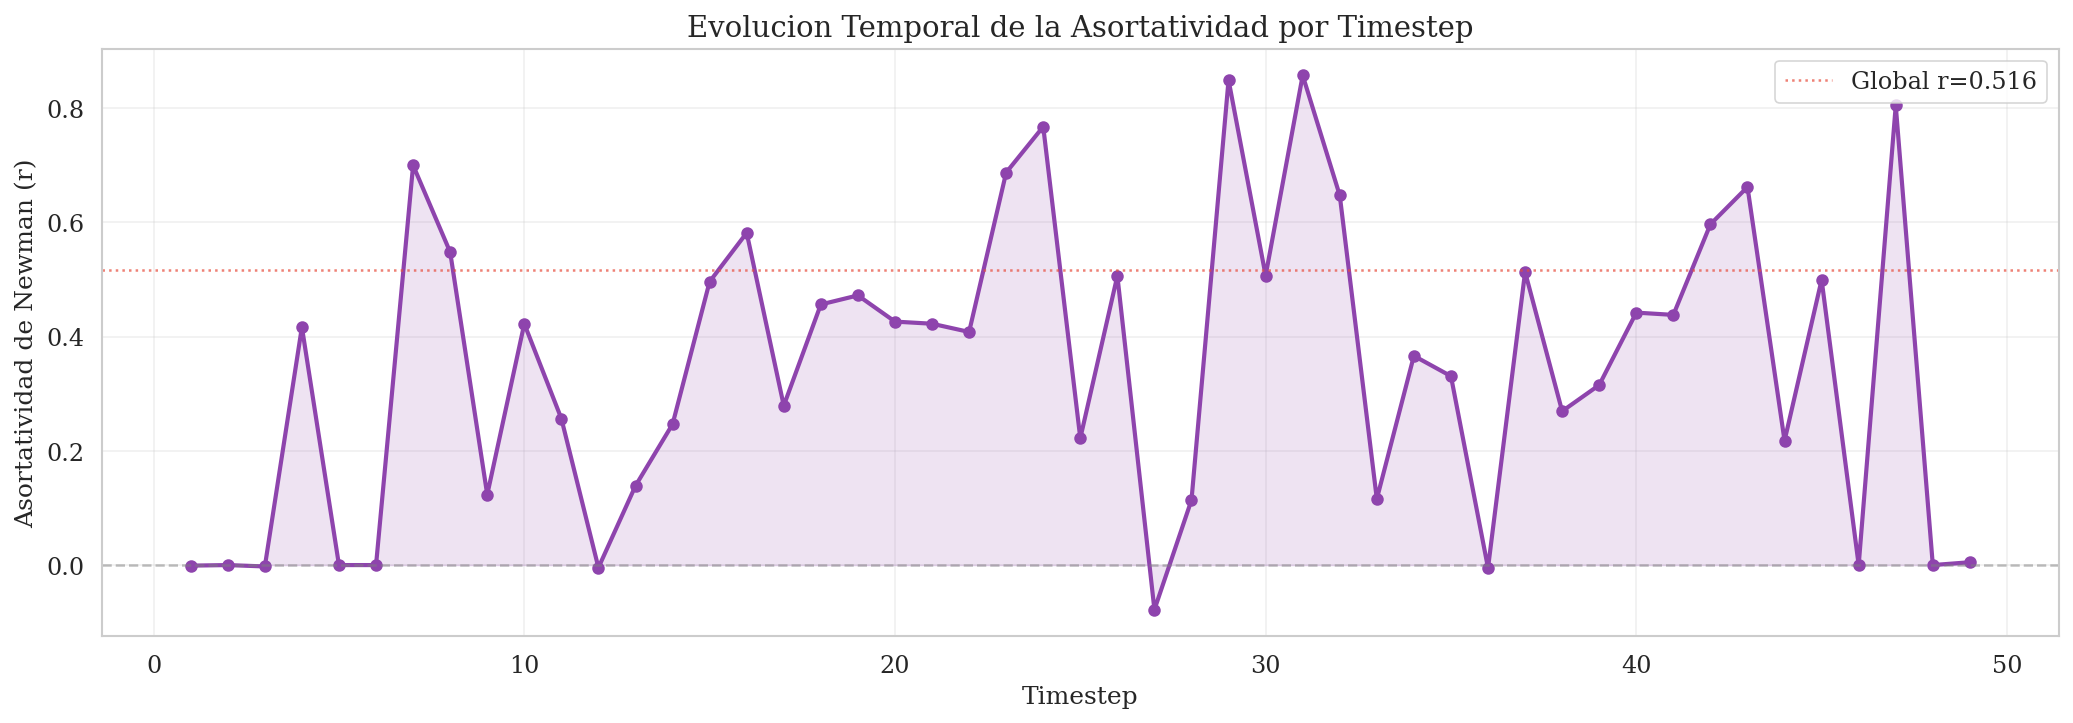

Rango de asortatividad: [-0.078, 0.857]
Timesteps con heterofilia (r<0): 6


In [5]:
# === 1.3 Evolucion Temporal de Asortatividad ===
timesteps = sorted(df['timestep'].unique())
assort_temporal = []

for ts in timesteps:
    ts_nodes = set(df.loc[(df['timestep'] == ts) & (df['label'] >= 0), 'txId'])
    if len(ts_nodes) < 10:
        assort_temporal.append(np.nan)
        continue
    G_ts = G.subgraph(ts_nodes).copy()
    if G_ts.number_of_edges() < 5:
        assort_temporal.append(np.nan)
        continue
    try:
        r = nx.attribute_assortativity_coefficient(G_ts, 'label')
        assort_temporal.append(r)
    except:
        assort_temporal.append(np.nan)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(timesteps, assort_temporal, 'o-', color='#8e44ad', linewidth=2, ms=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=r_global, color='#e74c3c', linestyle=':', alpha=0.7, label=f'Global r={r_global:.3f}')
ax.fill_between(timesteps, 0, assort_temporal, alpha=0.15, color='#8e44ad')
ax.set_xlabel('Timestep')
ax.set_ylabel('Asortatividad de Newman (r)')
ax.set_title('Evolucion Temporal de la Asortatividad por Timestep')
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./figuras/temporal_assortativity.png', dpi=300)
plt.show()

print(f"Rango de asortatividad: [{np.nanmin(assort_temporal):.3f}, {np.nanmax(assort_temporal):.3f}]")
print(f"Timesteps con heterofilia (r<0): {sum(1 for r in assort_temporal if r is not None and r < 0)}")

### Interpretacion de Asortatividad

> **Si $r > 0$ consistentemente:** El message passing de GCN (promediar features de vecinos)
> refuerza la senal de clase. Esto es ideal para GCN.
>
> **Si $r$ varia mucho entre timesteps:** El grafo tiene *zonas de homofilia y heterofilia mixtas*.
> Esto justifica usar **GAT** (Graph Attention Networks) que puede aprender a *ignorar*
> vecinos de clase distinta mediante pesos de atencion.
>
> **Si hay timesteps con $r < 0$:** Existe heterofilia (nodos ilicitos conectan con licitos).
> Esto es comun en fraude financiero (los lavadores necesitan interactuar con exchanges licitos).
> Se recomienda **H2GCN** o **FAGCN** (Frequency Adaptive GCN) que pueden manejar grafos heterofilo.

---
# 2. Topological Feature Informativeness (TFI) y Redundancia

## Problema de Doble Conteo

Las features 95-166 del dataset Elliptic son **agregaciones del vecindario** (promedios, sumas
de features de transacciones vecinas). Cuando una GNN aplica message passing, *vuelve a agregar*
la informacion de los vecinos. Esto causa:

1. **Redundancia:** La GNN recalcula lo que las features 95-166 ya contienen.
2. **Doble conteo:** Un nodo "ve" la misma informacion dos veces, inflando su influencia.
3. **Correlacion espuria:** Features locales y agregadas pueden estar altamente correlacionadas.

## Topological Feature Informativeness (TFI)

Definimos TFI como la ganancia discriminativa que una feature obtiene al ser "suavizada"
por la topologia del grafo. Formalmente, para una feature $f$:

$$\text{TFI}(f) = \frac{\text{Fisher}(\tilde{A}X_f)}{\text{Fisher}(X_f)}$$

donde $\text{Fisher} = \frac{(\mu_{\text{illicit}} - \mu_{\text{licit}})^2}{\sigma^2_{\text{illicit}} + \sigma^2_{\text{licit}}}$

- $\text{TFI} > 1$: La feature **mejora** con la topologia -> *GNN-favored*
- $\text{TFI} < 1$: La feature **empeora** -> *GNN-disfavored*, mejor usarla como skip-connection

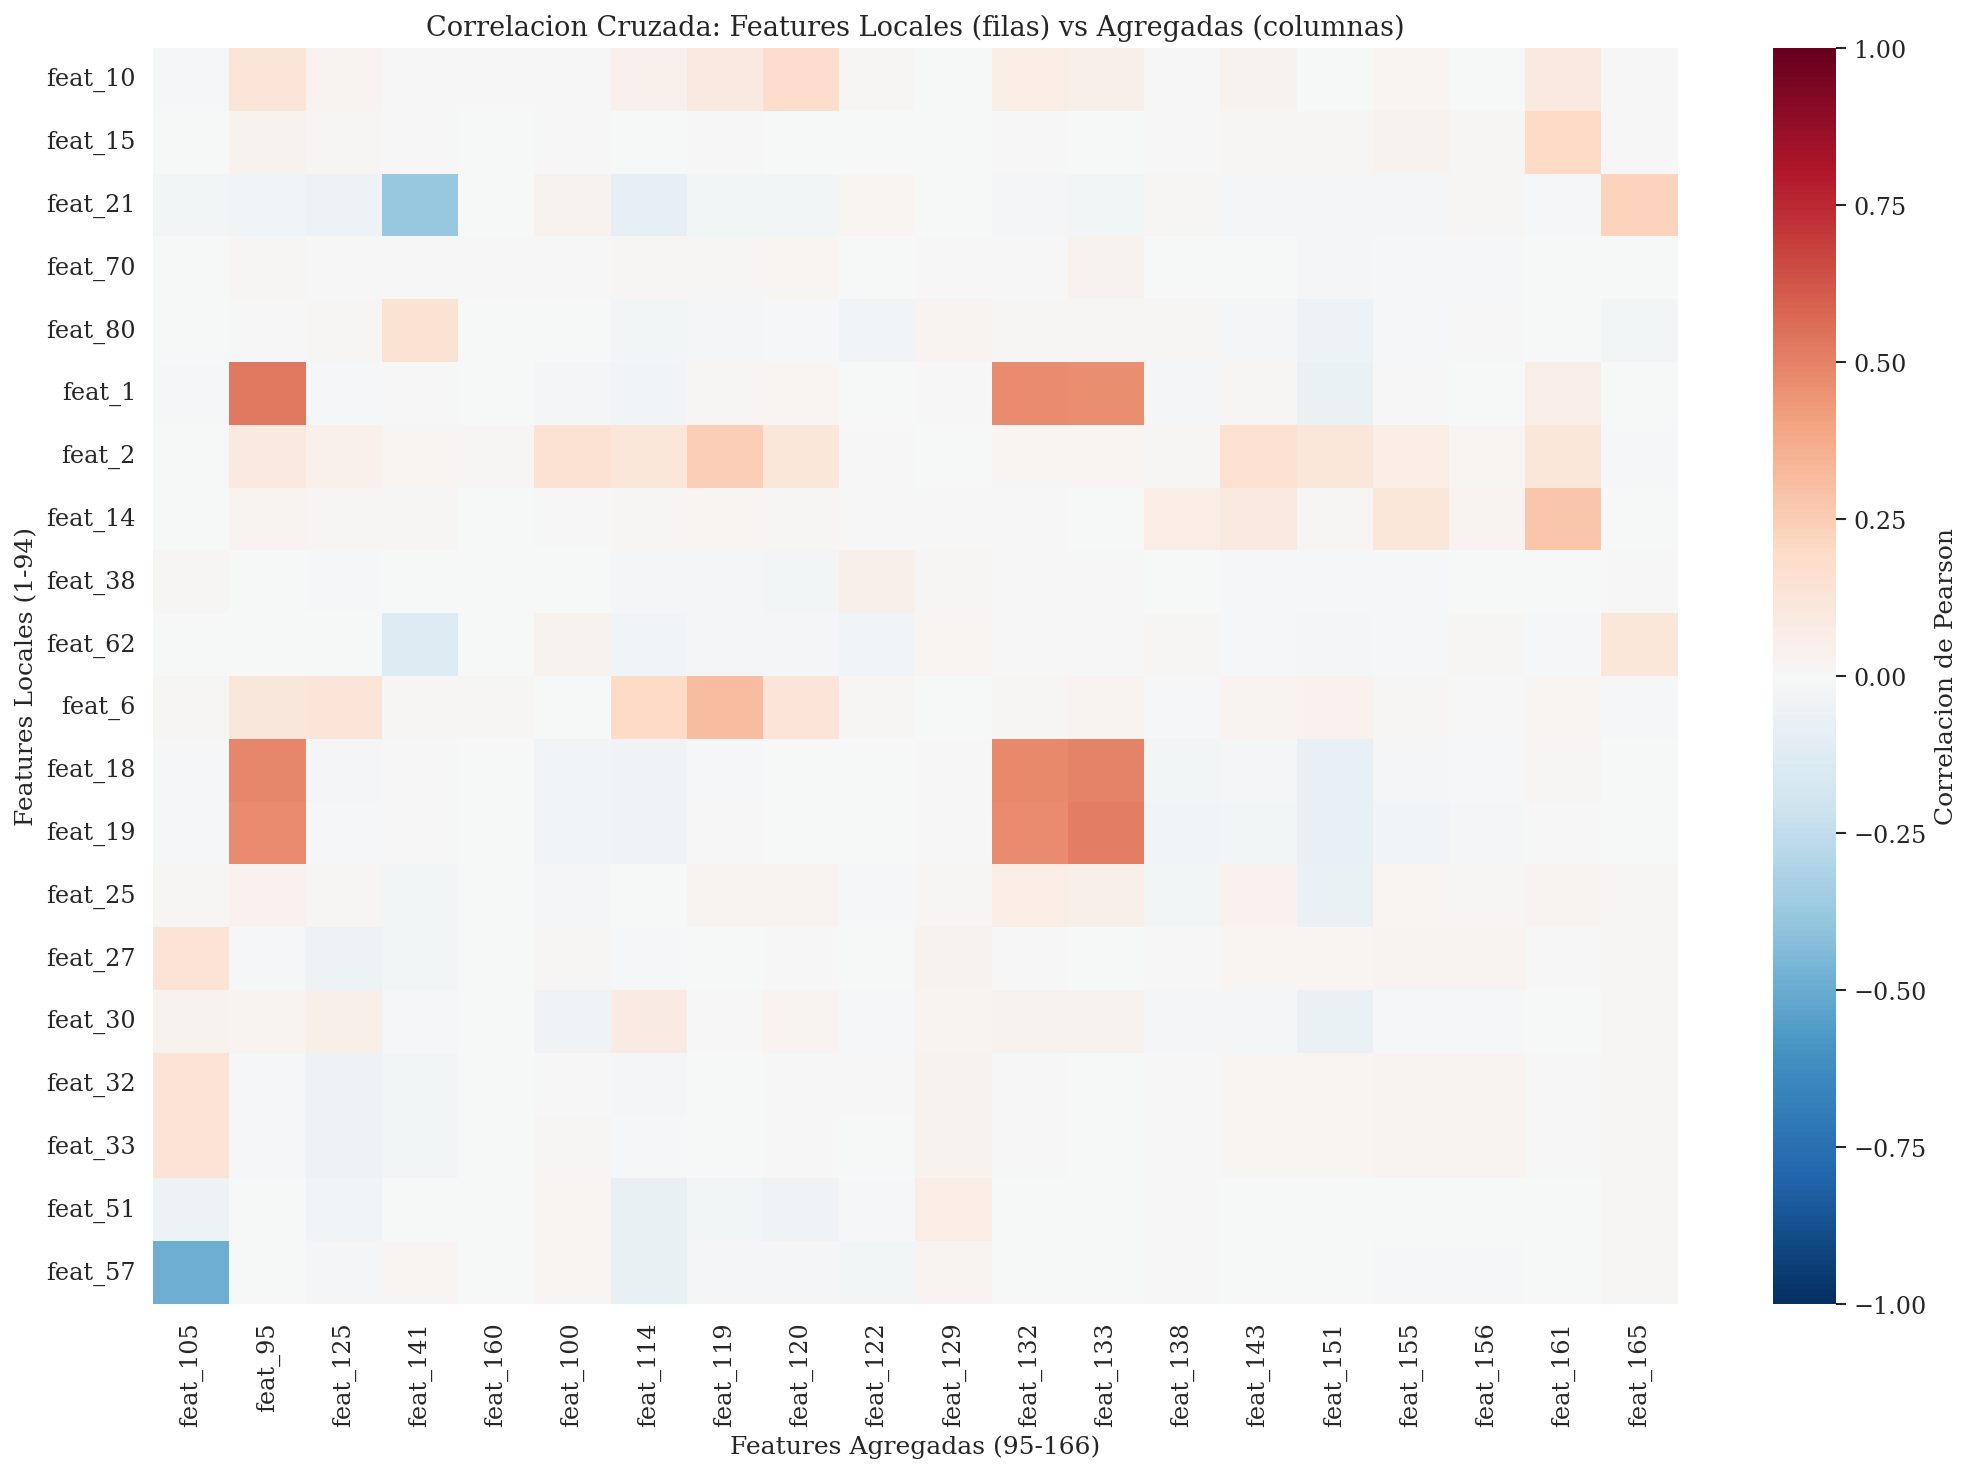

Pares con |correlacion| > 0.7: 0/400 (0.0%)
Correlacion promedio absoluta: 0.039


In [6]:
# === 2.1 Analisis de Redundancia: Correlacion Locales vs Agregadas ===
local_feats = [f'feat_{i}' for i in range(1, 95)]
agg_feats = [f'feat_{i}' for i in range(95, 167)]

# Matriz de correlacion cruzada
corr_cross = df[local_feats].corrwith(df[agg_feats].rename(
    columns={a: l for a, l in zip(agg_feats, local_feats[:len(agg_feats)])}
))

# Correlacion completa entre subconjuntos (top features)
# Seleccionar top 20 locales y top 20 agregadas con mayor varianza
var_local = df[local_feats].var().nlargest(20).index.tolist()
var_agg = df[agg_feats].var().nlargest(20).index.tolist()

corr_matrix = df[var_local + var_agg].corr()
cross_block = corr_matrix.loc[var_local, var_agg]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cross_block, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'})
ax.set_title('Correlacion Cruzada: Features Locales (filas) vs Agregadas (columnas)', fontsize=13)
ax.set_xlabel('Features Agregadas (95-166)')
ax.set_ylabel('Features Locales (1-94)')
plt.tight_layout()
plt.savefig('./figuras/cross_correlation_heatmap.png', dpi=300)
plt.show()

# Resumen de correlaciones altas
high_corr = (cross_block.abs() > 0.7).sum().sum()
total_pairs = cross_block.shape[0] * cross_block.shape[1]
print(f"Pares con |correlacion| > 0.7: {high_corr}/{total_pairs} ({100*high_corr/total_pairs:.1f}%)")
print(f"Correlacion promedio absoluta: {cross_block.abs().mean().mean():.3f}")

In [7]:
# === 2.2 Topological Feature Informativeness (TFI) ===
import scipy.sparse as sp

# Construir matriz de adyacencia normalizada (A_tilde = D^-1/2 * A * D^-1/2)
nodes_list = list(G.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes_list)}
N = len(nodes_list)

# Matriz de adyacencia dispersa
rows, cols = [], []
for u, v in G.edges():
    if u in node_to_idx and v in node_to_idx:
        rows.append(node_to_idx[u])
        cols.append(node_to_idx[v])

A = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
# Simetrizar (para message passing no dirigido)
A = A + A.T
A = A.minimum(1)  # Binarizar
# Agregar self-loops
A = A + sp.eye(N)

# Normalizacion D^-1/2 A D^-1/2
degrees = np.array(A.sum(axis=1)).flatten()
D_inv_sqrt = sp.diags(np.power(degrees, -0.5, where=degrees > 0))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

# Preparar matriz de features alineada con nodes_list
df_indexed = df.set_index('txId')
feature_cols = [f'feat_{i}' for i in range(1, 167)]
X = np.zeros((N, len(feature_cols)))
labels = np.full(N, -1)

for node, idx in node_to_idx.items():
    if node in df_indexed.index:
        X[idx] = df_indexed.loc[node, feature_cols].values
        labels[idx] = df_indexed.loc[node, 'label']

print(f"Matriz de features X: {X.shape}")
print(f"Matriz A normalizada: {A_norm.shape}, nnz={A_norm.nnz:,}")

# Aplicar un paso de smoothing: X_smooth = A_norm @ X
X_smooth = A_norm @ X

# Fisher Score antes y despues
mask_illicit = labels == 1
mask_licit = labels == 0

def fisher_score(X, mask_pos, mask_neg):
    """Fisher score por columna: (mu1 - mu2)^2 / (var1 + var2)"""
    mu1 = X[mask_pos].mean(axis=0)
    mu2 = X[mask_neg].mean(axis=0)
    var1 = X[mask_pos].var(axis=0) + 1e-10
    var2 = X[mask_neg].var(axis=0) + 1e-10
    return (mu1 - mu2)**2 / (var1 + var2)

fisher_before = fisher_score(X, mask_illicit, mask_licit)
fisher_after = fisher_score(X_smooth, mask_illicit, mask_licit)

# TFI = fisher_after / fisher_before
tfi = fisher_after / (fisher_before + 1e-10)

tfi_df = pd.DataFrame({
    'feature': feature_cols,
    'fisher_before': fisher_before,
    'fisher_after': fisher_after,
    'TFI': tfi,
    'type': ['local' if i < 94 else 'agregada' for i in range(len(feature_cols))]
})

print("\n=== TOP 10 Features GNN-Favored (TFI > 1, mejoran con convolucion) ===")
print(tfi_df.nlargest(10, 'TFI')[['feature', 'type', 'fisher_before', 'fisher_after', 'TFI']].to_string(index=False))

print("\n=== TOP 10 Features GNN-Disfavored (TFI < 1, empeoran con convolucion) ===")
print(tfi_df.nsmallest(10, 'TFI')[['feature', 'type', 'fisher_before', 'fisher_after', 'TFI']].to_string(index=False))

Matriz de features X: (203769, 166)
Matriz A normalizada: (203769, 203769), nnz=672,479

=== TOP 10 Features GNN-Favored (TFI > 1, mejoran con convolucion) ===
 feature     type  fisher_before  fisher_after         TFI
feat_111 agregada   3.781572e-08      0.000338 8915.785280
feat_153 agregada   1.256046e-07      0.000852 6781.282018
feat_152 agregada   1.473598e-07      0.000867 5882.373604
feat_129 agregada   2.824949e-06      0.000277   97.887952
feat_136 agregada   1.323725e-05      0.000784   59.193482
feat_128 agregada   9.768313e-06      0.000317   32.483082
  feat_5    local   2.700415e-03      0.068486   25.361450
 feat_14    local   2.698455e-03      0.067019   24.836032
feat_110 agregada   7.092643e-06      0.000169   23.847493
 feat_15    local   3.895691e-04      0.004501   11.553078

=== TOP 10 Features GNN-Disfavored (TFI < 1, empeoran con convolucion) ===
 feature     type  fisher_before  fisher_after      TFI
feat_139 agregada       0.001733      0.000002 0.000868
fea

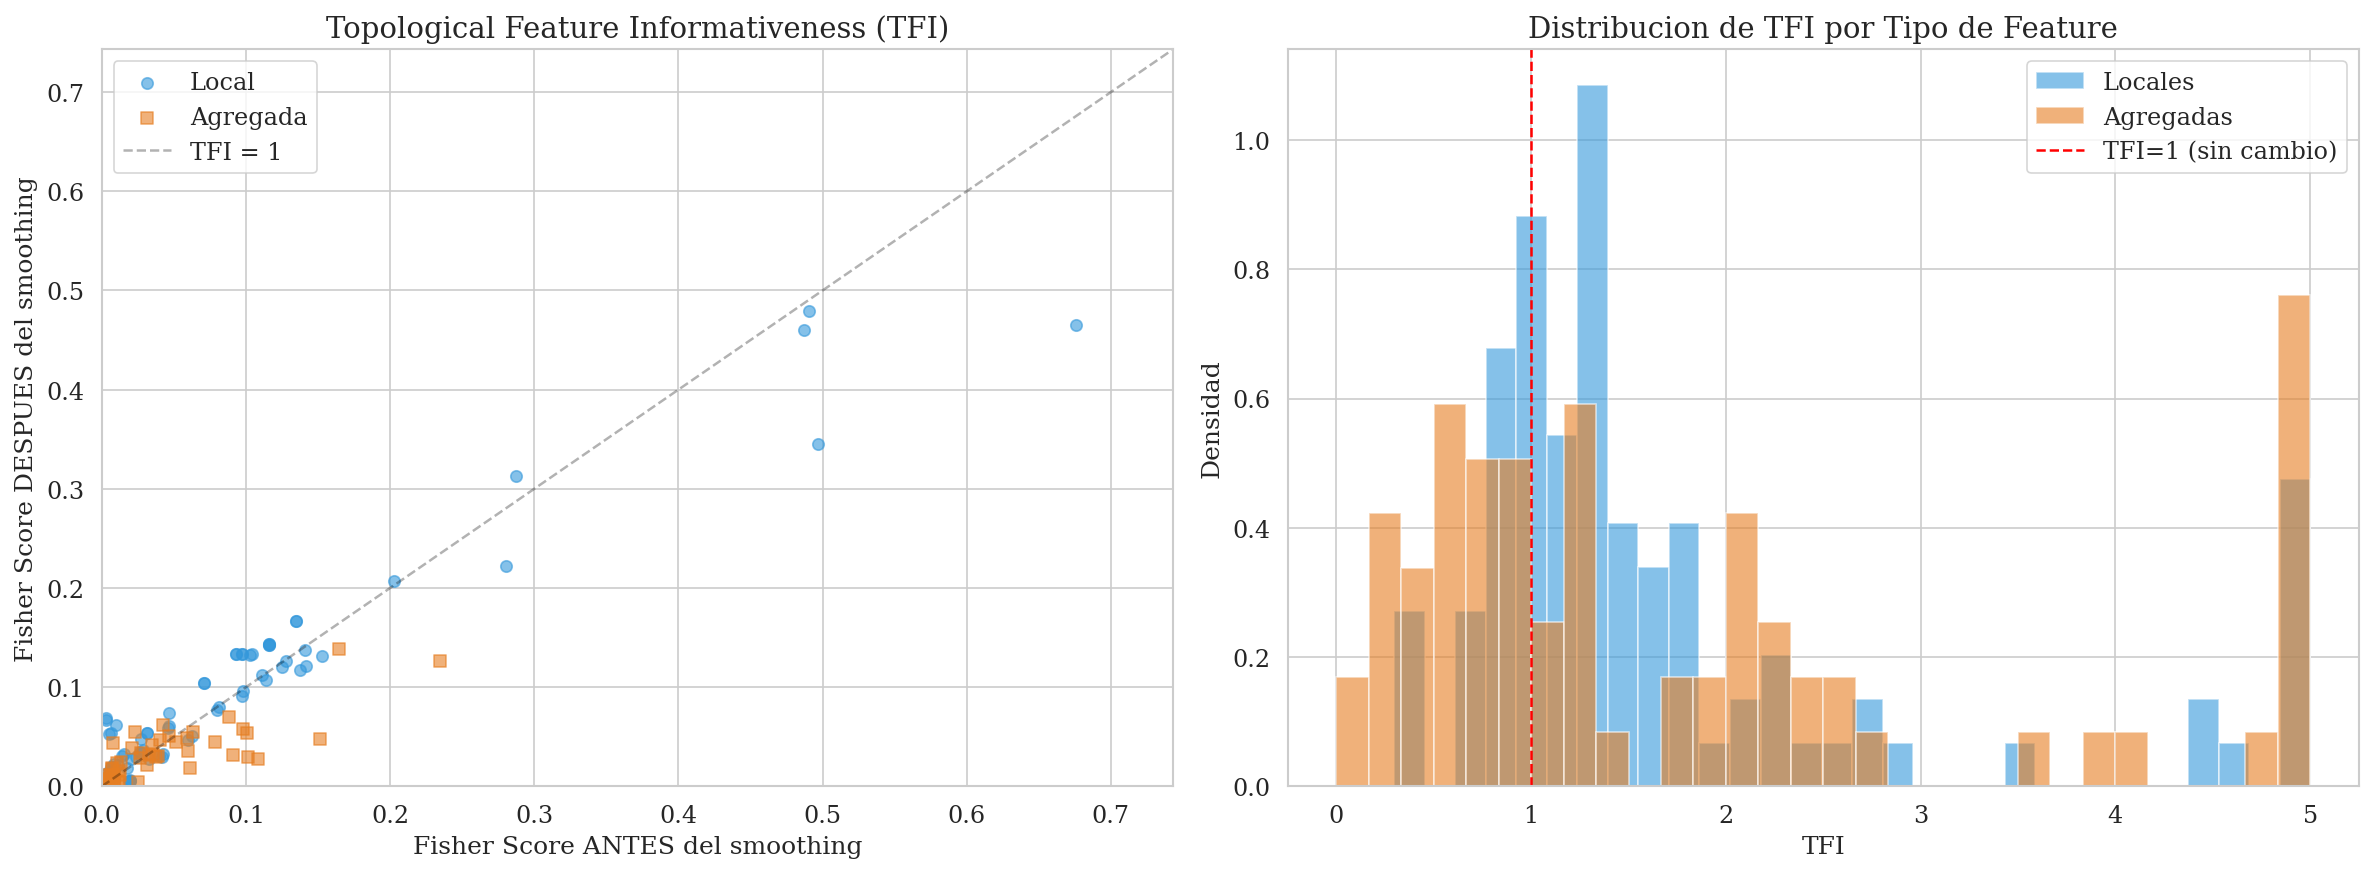


GNN-favored (TFI>1): 107 features
GNN-disfavored (TFI<1): 58 features
Features agregadas con TFI<1: 30/72


In [8]:
# === 2.3 Visualizacion TFI ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TFI por tipo de feature
for ftype, color, marker in [('local', '#3498db', 'o'), ('agregada', '#e67e22', 's')]:
    mask = tfi_df['type'] == ftype
    axes[0].scatter(tfi_df.loc[mask, 'fisher_before'], tfi_df.loc[mask, 'fisher_after'],
                    c=color, marker=marker, alpha=0.6, s=30, label=ftype.capitalize())

# Linea diagonal (TFI = 1)
lim = max(tfi_df['fisher_before'].max(), tfi_df['fisher_after'].max()) * 1.1
axes[0].plot([0, lim], [0, lim], 'k--', alpha=0.3, label='TFI = 1')
axes[0].set_xlabel('Fisher Score ANTES del smoothing')
axes[0].set_ylabel('Fisher Score DESPUES del smoothing')
axes[0].set_title('Topological Feature Informativeness (TFI)')
axes[0].legend(frameon=True)
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)

# Histograma de TFI
axes[1].hist(tfi_df.loc[tfi_df['type']=='local', 'TFI'].clip(0, 5), bins=30,
             alpha=0.6, color='#3498db', label='Locales', density=True)
axes[1].hist(tfi_df.loc[tfi_df['type']=='agregada', 'TFI'].clip(0, 5), bins=30,
             alpha=0.6, color='#e67e22', label='Agregadas', density=True)
axes[1].axvline(x=1.0, color='red', linestyle='--', label='TFI=1 (sin cambio)')
axes[1].set_xlabel('TFI')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribucion de TFI por Tipo de Feature')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.savefig('./figuras/tfi_analysis.png', dpi=300)
plt.show()

# Resumen
n_favored = (tfi_df['TFI'] > 1).sum()
n_disfavored = (tfi_df['TFI'] < 1).sum()
print(f"\nGNN-favored (TFI>1): {n_favored} features")
print(f"GNN-disfavored (TFI<1): {n_disfavored} features")
print(f"Features agregadas con TFI<1: {((tfi_df['type']=='agregada') & (tfi_df['TFI']<1)).sum()}/{len(agg_feats)}")

### Interpretacion TFI

> **Si muchas features agregadas tienen TFI < 1:** Confirma el problema de doble conteo.
> Las features 95-166 ya contienen la informacion del vecindario, y la GNN re-agrega
> innecesariamente. **Solucion:** Usar solo features locales (1-94) como entrada a la GNN,
> o implementar **skip-connections** (residual connections) para preservar la informacion original.
>
> **Si features locales tienen TFI >> 1:** La topologia del grafo *amplifica* su poder
> discriminativo. Estas son las features que mas se benefician de la GNN.
>
> **Implicacion Arquitectonica:** Considerar usar **JK-Net** (Jumping Knowledge Networks)
> que concatena las representaciones de cada capa, permitiendo que el modelo seleccione
> automaticamente el nivel optimo de agregacion por nodo.

---
# 3. Analisis de Over-Smoothing y Profundidad de la GNN

## El Problema del Over-Smoothing

El over-smoothing es el fenomeno por el cual, al aplicar multiples capas de message passing,
las representaciones de **todos** los nodos convergen al mismo vector, perdiendo toda capacidad
discriminativa. Formalmente, al aplicar $k$ pasos:

$$X^{(k)} = \tilde{A}^k X$$

las representaciones colapsan exponencialmente hacia el subespacio dominante de $\tilde{A}$.

## Metricas de Diagnostico

**Energia de Dirichlet** mide la "rugosidad" de la senal en el grafo:

$$E(X^{(k)}) = \sum_{(i,j) \in E} ||x_i^{(k)} - x_j^{(k)}||^2$$

- Si $E \to 0$: Over-smoothing (nodos vecinos tienen la misma representacion).
- El numero de capas optimo es aquel antes de que $E$ caiga drasticamente.

**Mean Average Distance (MAD)** mide la separabilidad inter-clase:

$$\text{MAD}(k) = \frac{1}{|C_1||C_2|} \sum_{i \in C_1, j \in C_2} ||x_i^{(k)} - x_j^{(k)}||$$

In [14]:
import numpy as np
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# ==========================================
# 1. SANITIZACIÓN Y ESCALADO DE FEATURES
# ==========================================
# Reemplazar cualquier NaN o Inf heredado del dataset original con 0.0
X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# ==========================================
# 2. NORMALIZACIÓN SEGURA DE LA ADYACENCIA
# ==========================================
# Construir matriz de adyacencia dispersa
A = nx.adjacency_matrix(G, nodelist=list(node_to_idx.keys()))

# Truco GCN: Añadir self-loops (A_hat = A + I) para asegurar que ningún nodo tenga grado 0
A_hat = A + sp.eye(A.shape[0])

# Matriz de Grados (D)
D_hat = np.array(A_hat.sum(axis=1)).flatten()

# PROTECCIÓN CONTRA NAN: Evitar división por cero forzando a 1.0 los grados nulos
D_hat[D_hat == 0] = 1.0 

# D^(-1/2)
D_inv_sqrt = sp.diags(np.power(D_hat, -0.5))

# Matriz de Adyacencia Normalizada (A_norm)
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

# ==========================================
# 3. PREPARACIÓN VECTORIZADA (Rendimiento)
# ==========================================
# Extraer índices de aristas para cálculo vectorizado (sin bucles for)
edges_idx = np.array([(node_to_idx[u], node_to_idx[v]) 
                      for u, v in G.edges() if u in node_to_idx and v in node_to_idx])

# Muestreo de 50,000 aristas para la Energía de Dirichlet
if len(edges_idx) > 50000:
    idx_sample = np.random.choice(len(edges_idx), 50000, replace=False)
    edges_sample = edges_idx[idx_sample]
else:
    edges_sample = edges_idx

u_idx = edges_sample[:, 0]
v_idx = edges_sample[:, 1]

# ==========================================
# 4. SIMULACIÓN DE OVER-SMOOTHING
# ==========================================
K_MAX = 10
X_k = X_scaled.copy()

dirichlet_energies = []
mad_inter_values = []
mad_intra_values = []

print("Iniciando simulación de propagación GCN...")

for k in range(K_MAX + 1):
    if k > 0:
        # Message Passing Matricial (O(E) de complejidad usando sparse)
        X_k = A_norm @ X_k
    
    # --- Energía de Dirichlet (Vectorizada) ---
    # Suma de las distancias euclidianas al cuadrado entre nodos conectados
    energy = np.sum((X_k[u_idx] - X_k[v_idx])**2)
    dirichlet_energies.append(energy)
    
    # --- Mean Average Distance (MAD) ---
    illicit_repr = X_k[mask_illicit]
    licit_repr = X_k[mask_licit]
    
    n_sample = min(500, len(illicit_repr), len(licit_repr))
    idx_ill = np.random.choice(len(illicit_repr), n_sample, replace=False)
    idx_lic = np.random.choice(len(licit_repr), n_sample, replace=False)
    
    # MAD Inter-clase
    dist_inter = cdist(illicit_repr[idx_ill], licit_repr[idx_lic], metric='euclidean')
    mad_inter = dist_inter.mean()
    mad_inter_values.append(mad_inter)
    
    # MAD Intra-clase (para la clase ilícita)
    dist_intra = cdist(illicit_repr[idx_ill[:200]], illicit_repr[idx_ill[:200]], metric='euclidean')
    mad_intra = dist_intra[np.triu_indices_from(dist_intra, k=1)].mean()
    mad_intra_values.append(mad_intra)
    
    print(f"Capa {k:2d} | Dirichlet: {energy:10.1f} | MAD Inter: {mad_inter:.4f} | MAD Intra (Ill): {mad_intra:.4f}")

Iniciando simulación de propagación GCN...
Capa  0 | Dirichlet: 38569498.7 | MAD Inter: 16.8478 | MAD Intra (Ill): 9.4142
Capa  1 | Dirichlet: 37066757.0 | MAD Inter: 17.0143 | MAD Intra (Ill): 12.0272
Capa  2 | Dirichlet: 28258352.5 | MAD Inter: 18.5662 | MAD Intra (Ill): 13.5424
Capa  3 | Dirichlet: 25186621.1 | MAD Inter: 19.9264 | MAD Intra (Ill): 13.0805
Capa  4 | Dirichlet: 24162821.4 | MAD Inter: 20.5853 | MAD Intra (Ill): 14.8006
Capa  5 | Dirichlet: 23919719.8 | MAD Inter: 20.4058 | MAD Intra (Ill): 15.3849
Capa  6 | Dirichlet: 23985899.4 | MAD Inter: 21.4602 | MAD Intra (Ill): 15.9480
Capa  7 | Dirichlet: 24166637.3 | MAD Inter: 24.0666 | MAD Intra (Ill): 18.7650
Capa  8 | Dirichlet: 24377403.9 | MAD Inter: 24.8867 | MAD Intra (Ill): 17.7065
Capa  9 | Dirichlet: 24581500.9 | MAD Inter: 24.0003 | MAD Intra (Ill): 16.0373
Capa 10 | Dirichlet: 24763915.5 | MAD Inter: 23.8334 | MAD Intra (Ill): 17.1861


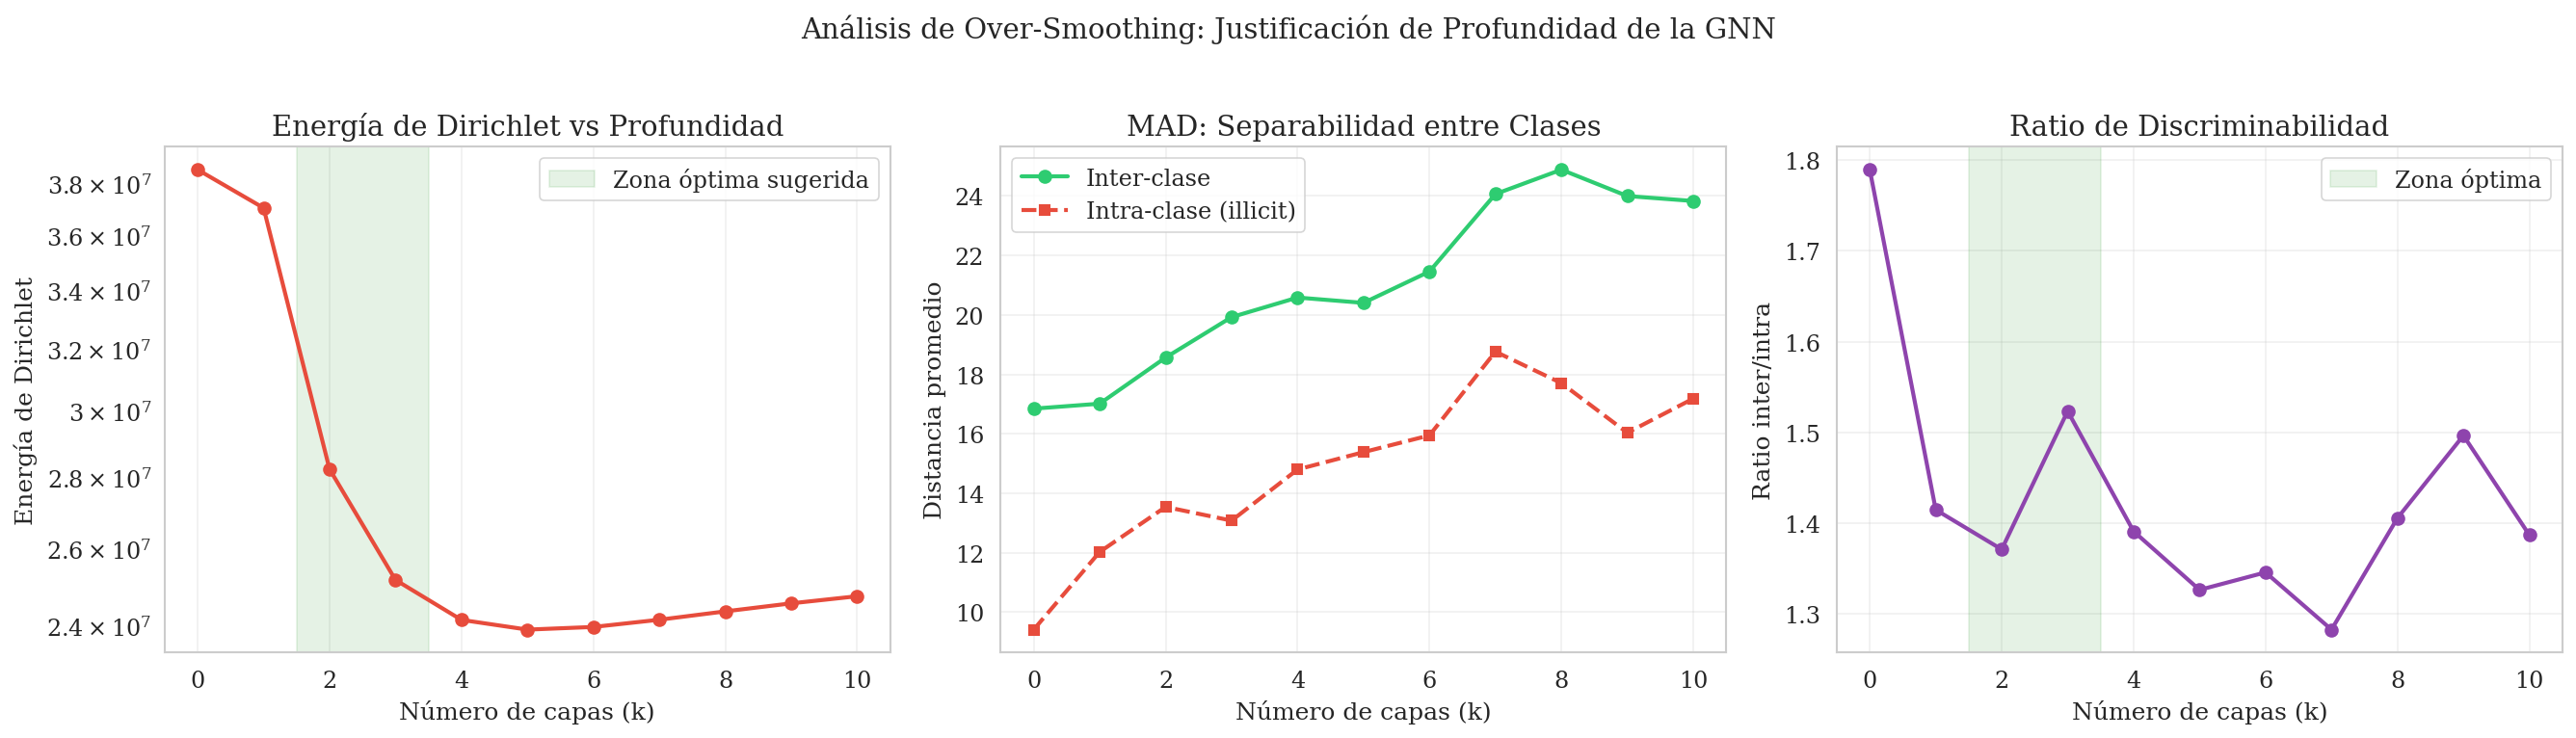


[+] RESULTADOS DEL ANÁLISIS DE PROFUNDIDAD:
 -> Profundidad óptima sugerida: k = 0 capas
 -> Ratio inter/intra en k=0: 1.7896
 -> Ratio inter/intra en k=1: 1.4147
 -> Caída de Dirichlet (Pérdida de señal) de k=0 a k=0: 0.0%


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Asegurar que el directorio existe para evitar FileNotFoundError
os.makedirs('./figuras', exist_ok=True)

# 2. Configuración de la figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_range = range(K_MAX + 1)

# --- Gráfica 1: Energía de Dirichlet ---
axes[0].plot(k_range, dirichlet_energies, 'o-', color='#e74c3c', linewidth=2, ms=6)
axes[0].set_xlabel('Número de capas (k)')
axes[0].set_ylabel('Energía de Dirichlet')
axes[0].set_title('Energía de Dirichlet vs Profundidad')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].axvspan(1.5, 3.5, alpha=0.1, color='green', label='Zona óptima sugerida')
axes[0].legend()

# --- Gráfica 2: MAD (Mean Average Distance) ---
# CORRECCIÓN: Usando las variables del script vectorizado
axes[1].plot(k_range, mad_inter_values, 'o-', color='#2ecc71', linewidth=2, ms=6, label='Inter-clase')
axes[1].plot(k_range, mad_intra_values, 's--', color='#e74c3c', linewidth=2, ms=5, label='Intra-clase (illicit)')
axes[1].set_xlabel('Número de capas (k)')
axes[1].set_ylabel('Distancia promedio')
axes[1].set_title('MAD: Separabilidad entre Clases')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

# --- Gráfica 3: Ratio de Discriminabilidad ---
# CORRECCIÓN: Usando las variables del script vectorizado
ratio = [m/i if i > 0 else 0 for m, i in zip(mad_inter_values, mad_intra_values)]

axes[2].plot(k_range, ratio, 'o-', color='#8e44ad', linewidth=2, ms=6)
axes[2].set_xlabel('Número de capas (k)')
axes[2].set_ylabel('Ratio inter/intra')
axes[2].set_title('Ratio de Discriminabilidad')
axes[2].grid(True, alpha=0.3)
axes[2].axvspan(1.5, 3.5, alpha=0.1, color='green', label='Zona óptima')
axes[2].legend()

plt.suptitle('Análisis de Over-Smoothing: Justificación de Profundidad de la GNN', fontsize=14, y=1.02)
plt.tight_layout()

# Guardar figura en alta calidad para el documento de tesis
plt.savefig('./figuras/oversmoothing_analysis.png', dpi=300, bbox_inches='tight')
plt.show() # Nota para Kaggle/Notebooks: plt.show() debe ir DESPUÉS de savefig.

# --- Conclusiones Numéricas ---
k_opt = np.argmax(ratio)
print(f"\n[+] RESULTADOS DEL ANÁLISIS DE PROFUNDIDAD:")
print(f" -> Profundidad óptima sugerida: k = {k_opt} capas")
print(f" -> Ratio inter/intra en k={k_opt}: {ratio[k_opt]:.4f}")
if len(ratio) > 1:
    print(f" -> Ratio inter/intra en k=1: {ratio[1]:.4f}")
if dirichlet_energies[0] > 0:
    caida = 100 * (1 - dirichlet_energies[k_opt] / dirichlet_energies[0])
    print(f" -> Caída de Dirichlet (Pérdida de señal) de k=0 a k={k_opt}: {caida:.1f}%")

### Interpretacion de Over-Smoothing

> **Si la Energia de Dirichlet cae drasticamente despues de $k=2$ o $k=3$:**
> Las representaciones se suavizan rapidamente. La GNN debe tener **2-3 capas maximo**.
> Arquitecturas como **GCN** o **GAT** con esta profundidad son adecuadas.
>
> **Si el ratio inter/intra tiene un pico claro:**
> Ese pico indica la profundidad optima. Antes del pico, la GNN no agrega suficiente
> informacion topologica. Despues, el over-smoothing destruye la separabilidad.
>
> **Mitigaciones si se necesitan mas capas:**
> - **Residual Connections:** $X^{(k+1)} = \tilde{A}X^{(k)} + X^{(k)}$
> - **DropEdge:** Eliminar aristas aleatoriamente durante entrenamiento
> - **PairNorm / NodeNorm:** Normalizar representaciones entre capas
> - **JK-Net:** Concatenar todas las capas intermedias

---
# 4. Dinamica de Nodos 'Unknown' y Desbalance Temporal

## El Problema de los Nodos Unknown

El 77% de las transacciones no tienen etiqueta (class = 'unknown'). Esto genera riesgos:

1. **Label Leakage en Message Passing:** Durante el entrenamiento, los nodos unknown actuan
   como "puentes" entre nodos illicit y licit. Si un nodo unknown esta topologicamente
   mas cerca de nodos illicit, su representacion se "contaminara" y propagara esa senal.

2. **Ruido de Propagacion:** Si los nodos unknown se usan en el grafo durante entrenamiento
   sin mascara, su senal (ambigua) se propaga a nodos etiquetados, degradando el aprendizaje.

3. **Desbalance Temporal:** La proporcion de illicit cambia entre timesteps,
   lo que afecta la calibracion del modelo y requiere funciones de perdida adaptativas.

In [11]:
# === 4.1 Distancia Topologica: Unknowns a Illicit vs Licit ===
from collections import deque

illicit_set = set(df.loc[df['class'] == 'illicit', 'txId'])
licit_set = set(df.loc[df['class'] == 'licit', 'txId'])
unknown_set = set(df.loc[df['class'] == 'unknown', 'txId'])

# BFS multi-source desde illicit y licit
def bfs_distance(G_undirected, source_set, target_set, max_dist=6):
    """BFS multi-source para calcular distancia minima de cada target a alguno de source."""
    distances = {}
    visited = set()
    queue = deque()
    
    for s in source_set:
        if s in G_undirected:
            queue.append((s, 0))
            visited.add(s)
    
    while queue:
        node, dist = queue.popleft()
        if dist > max_dist:
            break
        if node in target_set:
            distances[node] = dist
        for neighbor in G_undirected.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, dist + 1))
    
    return distances

G_undirected = G.to_undirected()
print("Calculando distancias BFS (esto puede tardar ~30s)...")

dist_to_illicit = bfs_distance(G_undirected, illicit_set, unknown_set)
dist_to_licit = bfs_distance(G_undirected, licit_set, unknown_set)
print(f"Unknowns con distancia a illicit: {len(dist_to_illicit):,}")
print(f"Unknowns con distancia a licit: {len(dist_to_licit):,}")

Calculando distancias BFS (esto puede tardar ~30s)...
Unknowns con distancia a illicit: 90,189
Unknowns con distancia a licit: 134,407


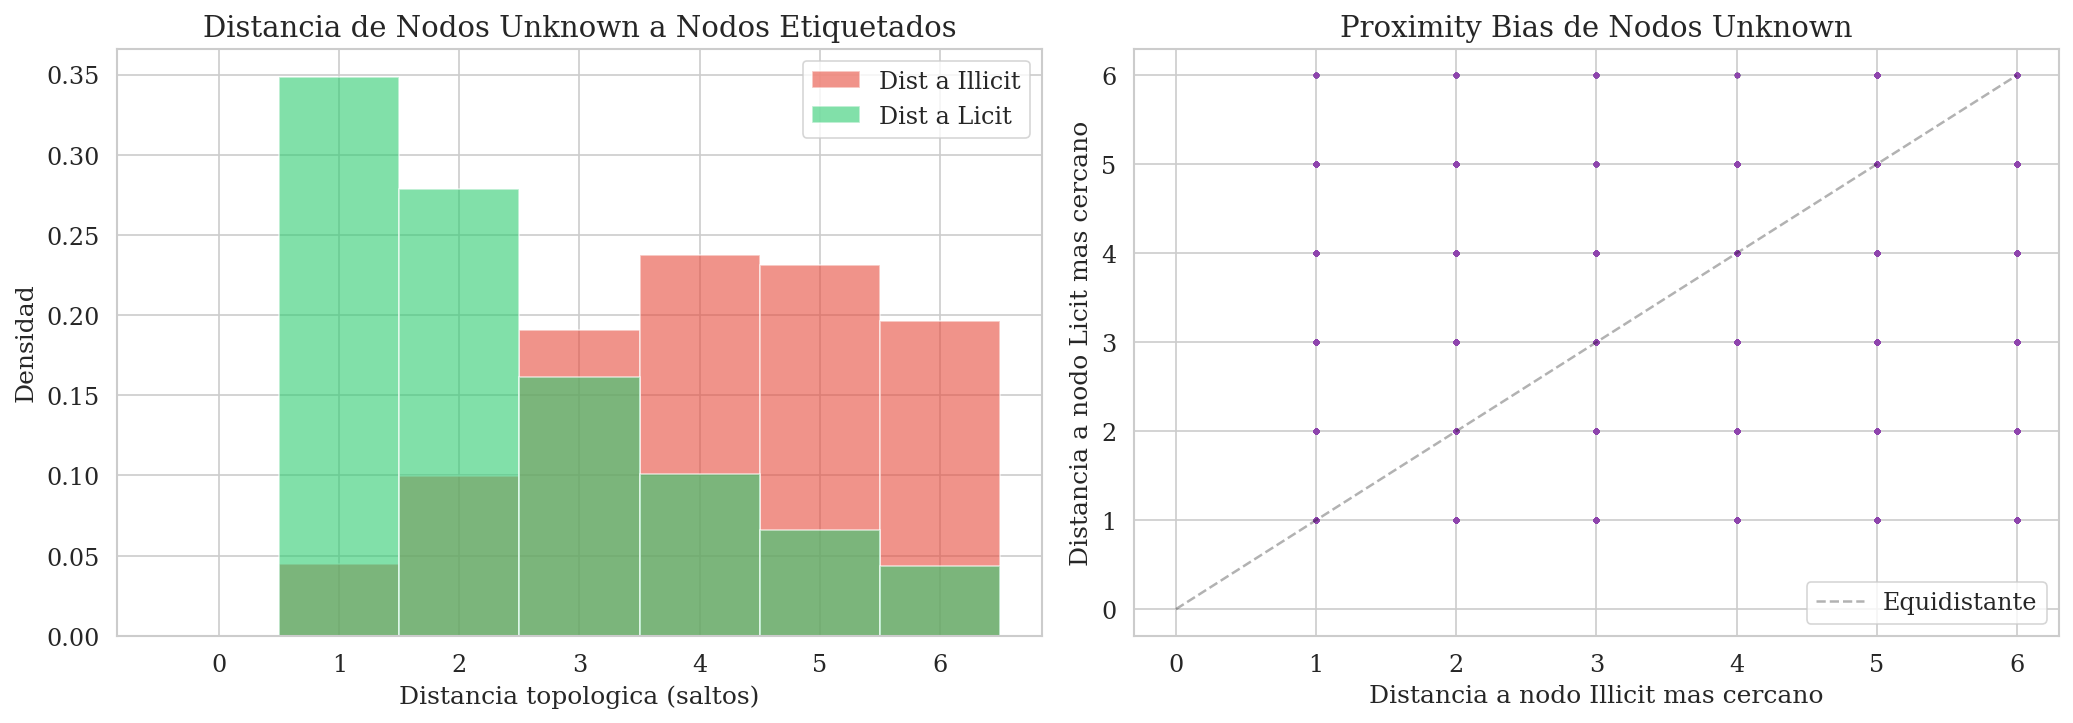


Unknowns mas cerca de ILLICIT: 6,447 (7.2%)
Unknowns mas cerca de LICIT:   79,786 (89.4%)
Equidistantes:                 3,012 (3.4%)


In [12]:
# === 4.2 Visualizacion de Distancias ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de distancias
d_ill = list(dist_to_illicit.values())
d_lic = list(dist_to_licit.values())

axes[0].hist(d_ill, bins=range(0, 8), alpha=0.6, color='#e74c3c', label='Dist a Illicit', density=True, align='left')
axes[0].hist(d_lic, bins=range(0, 8), alpha=0.6, color='#2ecc71', label='Dist a Licit', density=True, align='left')
axes[0].set_xlabel('Distancia topologica (saltos)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distancia de Nodos Unknown a Nodos Etiquetados')
axes[0].legend(frameon=True)
axes[0].set_xticks(range(0, 7))

# Scatter: distancia a illicit vs distancia a licit
common_unknowns = set(dist_to_illicit.keys()) & set(dist_to_licit.keys())
d_ill_common = [dist_to_illicit[n] for n in common_unknowns]
d_lic_common = [dist_to_licit[n] for n in common_unknowns]

axes[1].scatter(d_ill_common, d_lic_common, s=3, alpha=0.2, c='#8e44ad', rasterized=True)
axes[1].plot([0, 6], [0, 6], 'k--', alpha=0.3, label='Equidistante')
axes[1].set_xlabel('Distancia a nodo Illicit mas cercano')
axes[1].set_ylabel('Distancia a nodo Licit mas cercano')
axes[1].set_title('Proximity Bias de Nodos Unknown')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.savefig('./figuras/unknown_distances.png', dpi=300)
plt.show()

# Estadisticas
closer_to_illicit = sum(1 for n in common_unknowns if dist_to_illicit[n] < dist_to_licit[n])
closer_to_licit = sum(1 for n in common_unknowns if dist_to_licit[n] < dist_to_illicit[n])
equidist = len(common_unknowns) - closer_to_illicit - closer_to_licit
print(f"\nUnknowns mas cerca de ILLICIT: {closer_to_illicit:,} ({100*closer_to_illicit/len(common_unknowns):.1f}%)")
print(f"Unknowns mas cerca de LICIT:   {closer_to_licit:,} ({100*closer_to_licit/len(common_unknowns):.1f}%)")
print(f"Equidistantes:                 {equidist:,} ({100*equidist/len(common_unknowns):.1f}%)")

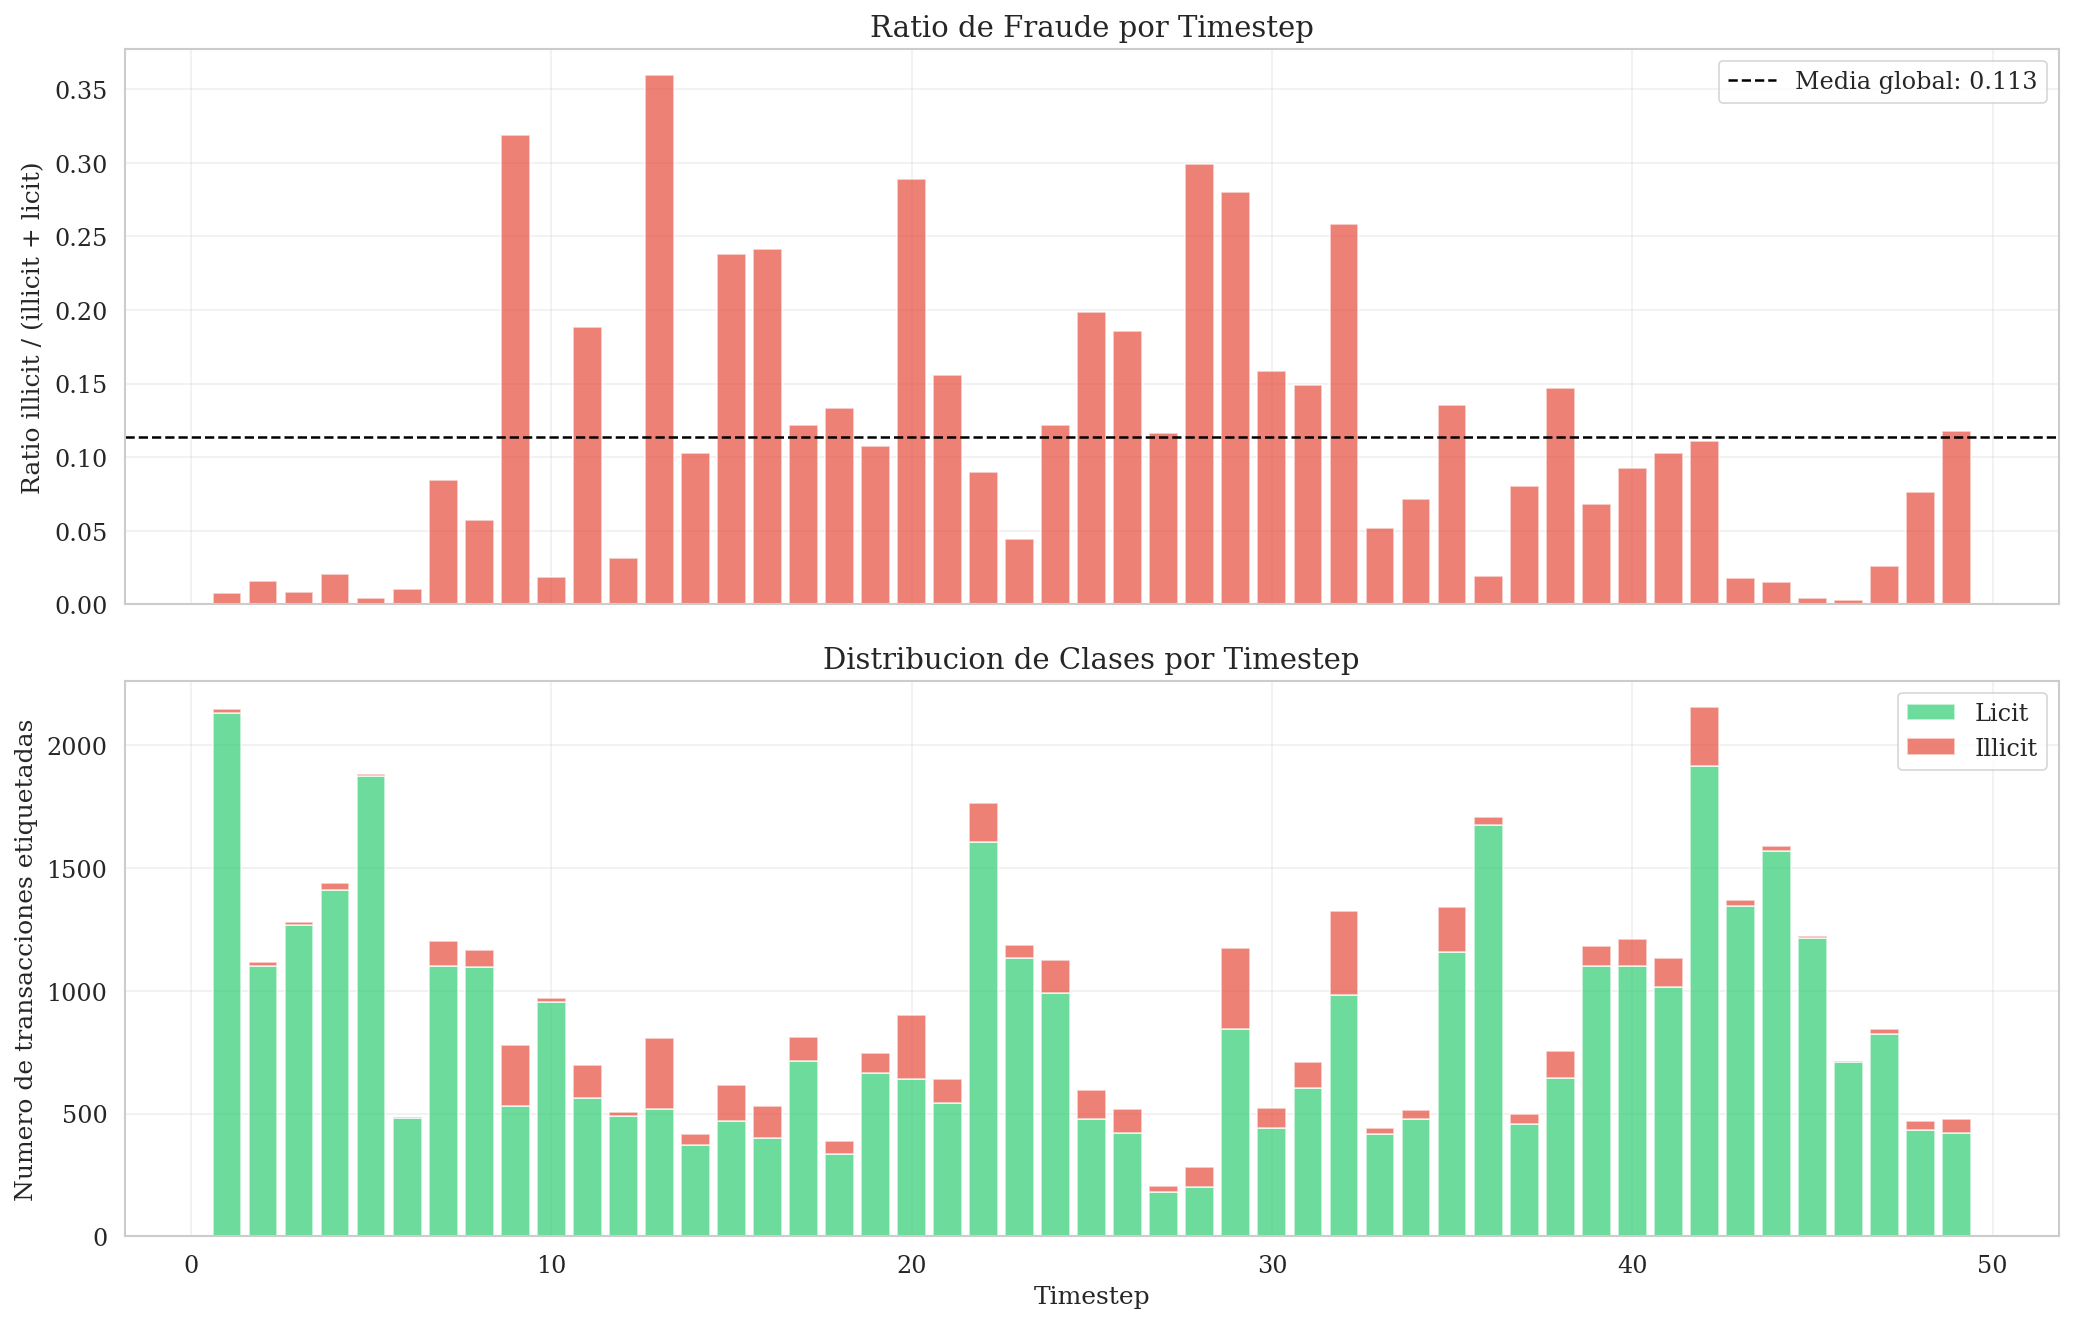

Ratio illicit - min: 0.003, max: 0.360
Coeficiente de variacion: 0.836
Timesteps sin nodos illicit: 0


In [13]:
# === 4.3 Ratio de Desbalance Temporal ===
ts_counts = df[df['class'].isin(['illicit', 'licit'])].groupby(['timestep', 'class']).size().unstack(fill_value=0)
ts_counts = ts_counts.reindex(columns=['illicit', 'licit'], fill_value=0)
ts_counts['illicit_ratio'] = ts_counts['illicit'] / (ts_counts['illicit'] + ts_counts['licit'])
ts_counts['total_labeled'] = ts_counts['illicit'] + ts_counts['licit']

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Ratio illicit
axes[0].bar(ts_counts.index, ts_counts['illicit_ratio'], color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].axhline(y=ts_counts['illicit_ratio'].mean(), color='black', linestyle='--',
                label=f"Media global: {ts_counts['illicit_ratio'].mean():.3f}")
axes[0].set_ylabel('Ratio illicit / (illicit + licit)')
axes[0].set_title('Ratio de Fraude por Timestep')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Conteo absoluto stacked
axes[1].bar(ts_counts.index, ts_counts['licit'], color='#2ecc71', alpha=0.7, label='Licit')
axes[1].bar(ts_counts.index, ts_counts['illicit'], bottom=ts_counts['licit'],
            color='#e74c3c', alpha=0.7, label='Illicit')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Numero de transacciones etiquetadas')
axes[1].set_title('Distribucion de Clases por Timestep')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figuras/temporal_imbalance.png', dpi=300)
plt.show()

print(f"Ratio illicit - min: {ts_counts['illicit_ratio'].min():.3f}, max: {ts_counts['illicit_ratio'].max():.3f}")
print(f"Coeficiente de variacion: {ts_counts['illicit_ratio'].std()/ts_counts['illicit_ratio'].mean():.3f}")
print(f"Timesteps sin nodos illicit: {(ts_counts['illicit'] == 0).sum()}")

### Interpretacion: Nodos Unknown y Desbalance

> **Si los unknowns estan mas cerca de nodos licit:**
> Es seguro incluirlos en el grafo durante el message passing (no propagaran senal de fraude).
> Se puede usar el grafo completo para entrenamiento inductivo.
>
> **Si el ratio illicit/total varia mucho entre timesteps (CV > 0.5):**
> El desbalance es *inestable*. Un peso fijo en la funcion de perdida (Weighted BCE) no es
> optimo. Se recomienda:
> - **Focal Loss:** $FL(p) = -\alpha(1-p)^\gamma \log(p)$, que focaliza el aprendizaje en ejemplos dificiles.
> - **Class-Balanced Loss** recalculado por timestep en Walk-Forward Validation.
> - **SMOTE topologico** o GraphSMOTE para generar nodos sinteticos de la clase minoritaria.

---
# 5. Mineria de Motifs Financieros (Fan-in / Fan-out)

## Patrones de Lavado de Dinero

Los criminales financieros usan patrones topologicos reconocibles:

| Patron | Estructura | In/Out Degree |
|---|---|---|
| **Smurfing** | Dividir un monto grande en muchas transacciones pequenas | Bajo In / Alto Out |
| **Layering** | Cadena larga de transacciones para ocultar origen | In=1 / Out=1 (cadena) |
| **Fan-in** | Multiples fuentes depositan en un unico destino (recoleccion) | Alto In / Bajo Out |
| **Fan-out** | Un origen distribuye fondos a multiples destinos | Bajo In / Alto Out |

El ratio $R = \frac{\text{In-Degree}}{\text{Out-Degree}}$ discrimina estos patrones:
- $R \gg 1$: Pattern Fan-in (recolector)
- $R \ll 1$: Pattern Fan-out (distribuidor/smurf)
- $R \approx 1$: Transaccion normal o layering

In [16]:
# === 5.1 Calculo de Ratios In/Out (vectorizado) ===
df['in_degree'] = df['txId'].map(dict(G.in_degree())).fillna(0).astype(int)
df['out_degree'] = df['txId'].map(dict(G.out_degree())).fillna(0).astype(int)

# Ratio con suavizado laplaciano para evitar division por cero
df['io_ratio'] = (df['in_degree'] + 1) / (df['out_degree'] + 1)
df['log_io_ratio'] = np.log2(df['io_ratio'])

# Clasificacion de patron topologico
def classify_motif(row):
    if row['in_degree'] == 0 and row['out_degree'] == 0:
        return 'isolated'
    elif row['in_degree'] > 3 * (row['out_degree'] + 1):
        return 'fan-in'
    elif row['out_degree'] > 3 * (row['in_degree'] + 1):
        return 'fan-out'
    elif row['in_degree'] <= 1 and row['out_degree'] <= 1 and (row['in_degree'] + row['out_degree']) > 0:
        return 'chain'
    else:
        return 'mixed'

df['motif'] = df.apply(classify_motif, axis=1)

# Estadisticas por clase
motif_stats = df[df['class'].isin(['illicit', 'licit'])].groupby(['class', 'motif']).size().unstack(fill_value=0)
motif_pct = motif_stats.div(motif_stats.sum(axis=1), axis=0) * 100

print("=== Distribucion de Motifs por Clase (%) ===")
print(motif_pct.round(2).to_string())

=== Distribucion de Motifs por Clase (%) ===
motif    chain  fan-in  fan-out  mixed
class                                 
illicit  89.79    1.12     0.00   9.09
licit    59.92    5.75     1.91  32.41


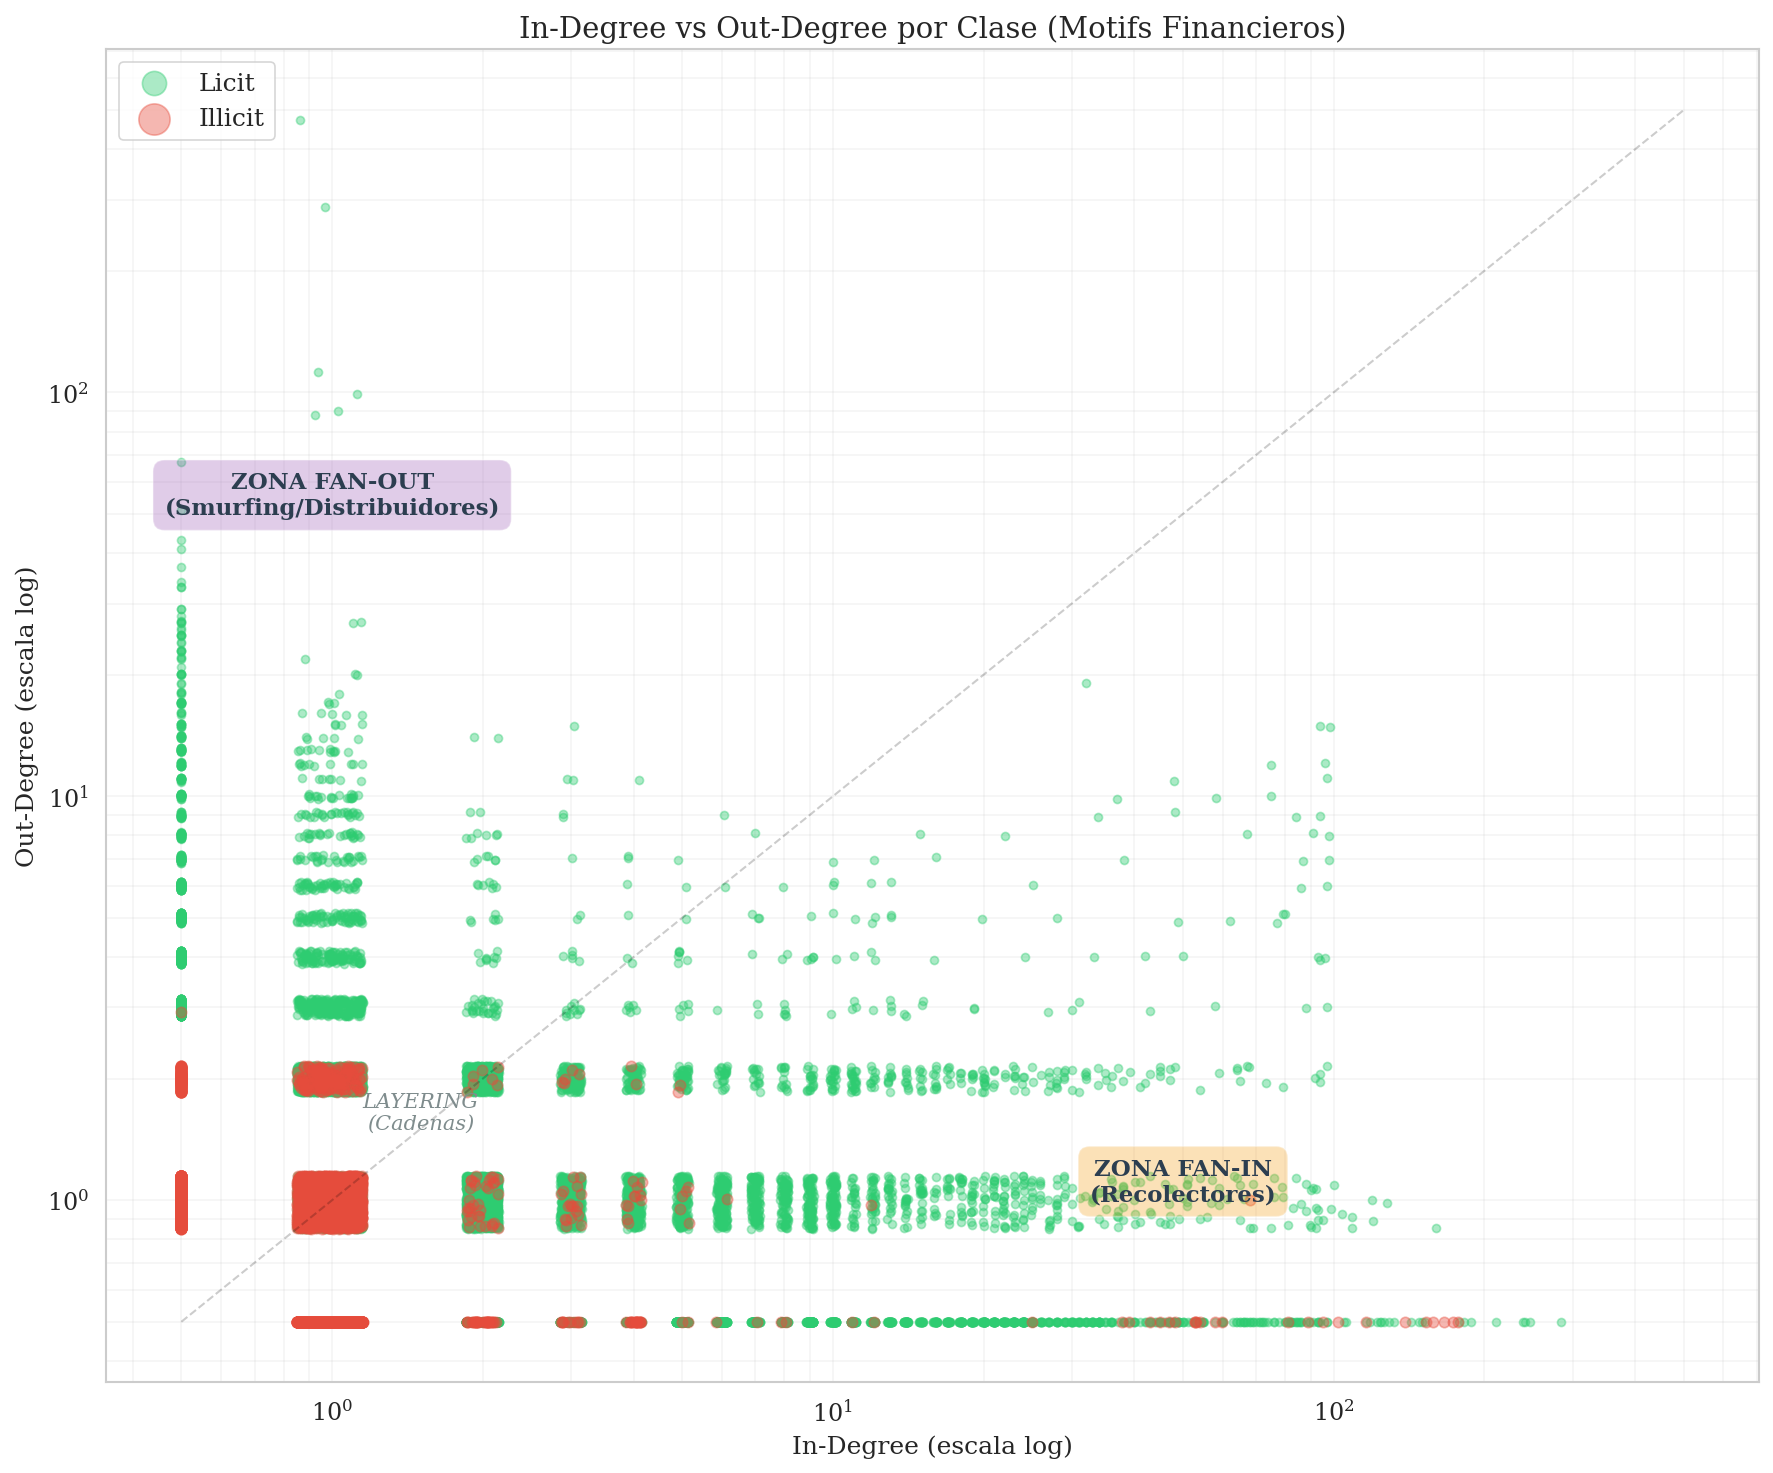

In [17]:
# === 5.2 Scatter Plot In-Degree vs Out-Degree (Log-Log) ===
df_labeled = df[df['class'].isin(['illicit', 'licit'])].copy()
# Filtrar nodos aislados
df_plot = df_labeled[(df_labeled['in_degree'] > 0) | (df_labeled['out_degree'] > 0)].copy()

fig, ax = plt.subplots(figsize=(12, 10))

# Jitter para visualizacion (escala log)
jitter = 0.15

for cls, color, zorder, size in [('licit', '#2ecc71', 1, 15), ('illicit', '#e74c3c', 2, 25)]:
    mask = df_plot['class'] == cls
    x = df_plot.loc[mask, 'in_degree'] + np.random.uniform(-jitter, jitter, mask.sum())
    y = df_plot.loc[mask, 'out_degree'] + np.random.uniform(-jitter, jitter, mask.sum())
    ax.scatter(x.clip(lower=0.5), y.clip(lower=0.5), s=size, alpha=0.4,
               c=color, label=cls.capitalize(), zorder=zorder, rasterized=True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('In-Degree (escala log)')
ax.set_ylabel('Out-Degree (escala log)')
ax.set_title('In-Degree vs Out-Degree por Clase (Motifs Financieros)', fontsize=14)

# Anotaciones de zonas
ax.annotate('ZONA FAN-IN\n(Recolectores)', xy=(50, 1), fontsize=11,
            color='#2c3e50', fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f39c12', alpha=0.3))
ax.annotate('ZONA FAN-OUT\n(Smurfing/Distribuidores)', xy=(1, 50), fontsize=11,
            color='#2c3e50', fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#9b59b6', alpha=0.3))
ax.annotate('LAYERING\n(Cadenas)', xy=(1.5, 1.5), fontsize=10,
            color='#7f8c8d', fontstyle='italic', ha='center')

# Linea diagonal (In = Out)
ax.plot([0.5, 500], [0.5, 500], 'k--', alpha=0.2, linewidth=1)

ax.legend(fontsize=12, markerscale=3, frameon=True, fancybox=True, loc='upper left')
ax.grid(True, alpha=0.2, which='both')
plt.tight_layout()
plt.savefig('./figuras/fanin_fanout_scatter.png', dpi=300)
plt.show()

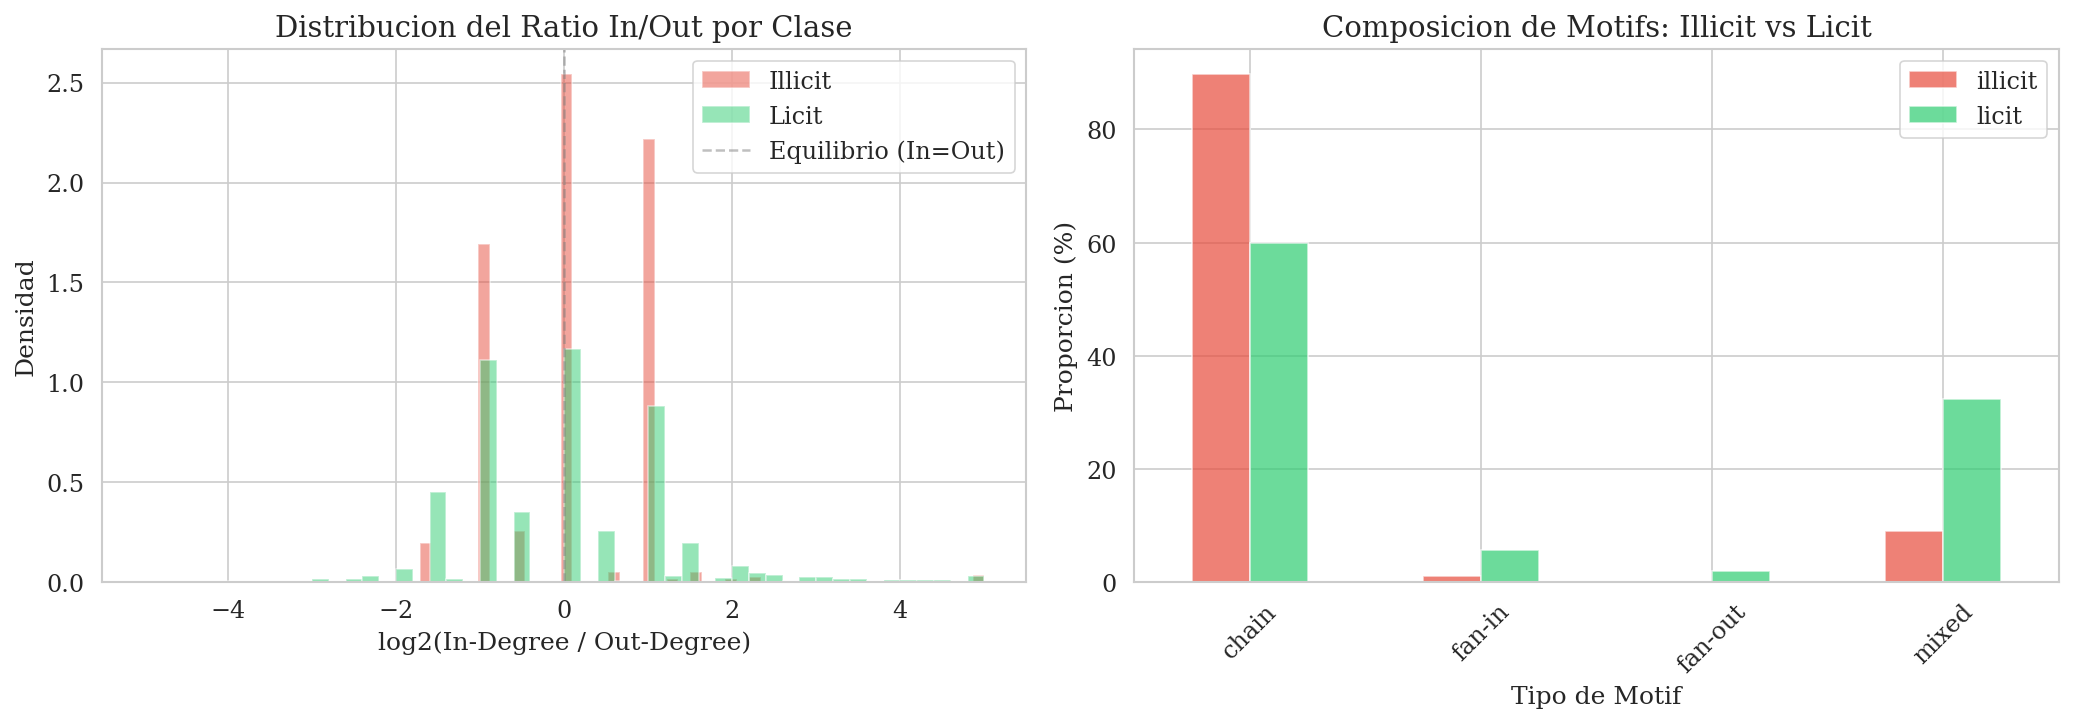


Mann-Whitney U test (In/Out ratio): U=102675209, p=2.00e-17
Illicit log2(ratio): mean=0.082, median=0.000
Licit   log2(ratio): mean=0.002, median=0.000


In [18]:
# === 5.3 Distribucion del Ratio In/Out por Clase ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_cls = {'illicit': '#e74c3c', 'licit': '#2ecc71'}

# Log2(In/Out ratio) distribution
for cls, color in colors_cls.items():
    vals = df_plot.loc[df_plot['class'] == cls, 'log_io_ratio'].dropna()
    axes[0].hist(vals.clip(-5, 5), bins=50, alpha=0.5, color=color, label=cls.capitalize(), density=True)

axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Equilibrio (In=Out)')
axes[0].set_xlabel('log2(In-Degree / Out-Degree)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribucion del Ratio In/Out por Clase')
axes[0].legend(frameon=True)

# Motif composition stacked bar
motif_pct_plot = motif_pct.T
motif_pct_plot.plot(kind='bar', ax=axes[1], color=[colors_cls.get(c, '#95a5a6') for c in motif_pct_plot.columns],
                     alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Tipo de Motif')
axes[1].set_ylabel('Proporcion (%)')
axes[1].set_title('Composicion de Motifs: Illicit vs Licit')
axes[1].legend(frameon=True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('./figuras/io_ratio_and_motifs.png', dpi=300)
plt.show()

# Test estadistico
from scipy.stats import mannwhitneyu
ill_ratio = df_plot.loc[df_plot['class'] == 'illicit', 'log_io_ratio'].dropna()
lic_ratio = df_plot.loc[df_plot['class'] == 'licit', 'log_io_ratio'].dropna()
stat, pval = mannwhitneyu(ill_ratio, lic_ratio, alternative='two-sided')
print(f"\nMann-Whitney U test (In/Out ratio): U={stat:.0f}, p={pval:.2e}")
print(f"Illicit log2(ratio): mean={ill_ratio.mean():.3f}, median={ill_ratio.median():.3f}")
print(f"Licit   log2(ratio): mean={lic_ratio.mean():.3f}, median={lic_ratio.median():.3f}")

### Interpretacion de Motifs Financieros

> **Si los nodos illicit muestran MAYOR proporcion de fan-out que licit:**
> Confirma la hipotesis de *smurfing* (fragmentacion de fondos ilicitos).
> La GNN debe tener suficiente profundidad (2+ capas) para capturar estos patrones a multiples saltos.
>
> **Si hay nodos illicit con patron fan-in:**
> Indica nodos *recolectores* (la fase final del lavado donde se reconcentran fondos).
> Estos nodos son targets criticos para deteccion.
>
> **Si el ratio In/Out es estadisticamente diferente entre clases (p < 0.05):**
> El grado dirigido tiene poder discriminativo. Considerar incluir In-Degree y Out-Degree
> como features explicitas adicionales, o usar **arquitecturas que preserven la direccionalidad**
> (DiGCN, DGNN) en lugar de simetrizar la matriz de adyacencia.

---
# Resumen: Decisiones Arquitectonicas Justificadas por el EDA

| Analisis | Resultado Esperado | Decision Arquitectonica |
|---|---|---|
| 1. Asortatividad | r > 0 pero variable | GAT con atencion selectiva |
| 2. TFI / Redundancia | Features agregadas redundantes con convolucion | Usar solo features locales (1-94) + skip-connections |
| 3. Over-Smoothing | Energia de Dirichlet colapsa en k>3 | GNN con 2-3 capas + residual connections |
| 4. Unknowns | Mayoria cerca de licit | Seguro incluir en grafo; Focal Loss para desbalance |
| 5. Motifs | Fan-out mas comun en illicit | Preservar direccionalidad; features de grado explicitas |

> **Arquitectura Propuesta (sujeta a resultados):**
> GAT de 2-3 capas con features locales (1-94), residual connections,
> entrenamiento con Focal Loss y Walk-Forward Validation temporal.